<a href="https://colab.research.google.com/github/SRIPATHY-113/Smart-Health-Analysis/blob/main/ML_Final_source.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All libraries imported successfully!
✅ Datasets loaded successfully!

Diabetes Dataset Shape: (768, 9)
Heart Disease Dataset Shape: (303, 14)

🔧 Preprocessing Diabetes...
✅ Training set: (614, 8)
✅ Testing set: (154, 8)

🔧 Preprocessing Heart Disease...
✅ Training set: (242, 13)
✅ Testing set: (61, 13)

Training Models for Diabetes

🔄 Training Logistic Regression...
✅ Logistic Regression: Accuracy=0.7078, F1=0.5455, ROC-AUC=0.8130

🔄 Training Decision Tree...
✅ Decision Tree: Accuracy=0.7597, F1=0.6783, ROC-AUC=0.7610

🔄 Training Random Forest...
✅ Random Forest: Accuracy=0.7792, F1=0.6600, ROC-AUC=0.8179

🔄 Training SVM...
✅ SVM: Accuracy=0.7403, F1=0.6000, ROC-AUC=0.7964

🔄 Training Neural Network...
✅ Neural Network: Accuracy=0.7468, F1=0.6061, ROC-AUC=0.8185

🔄 Training Naive Bayes...
✅ Naive Bayes: Accuracy=0.7013, F1=0.5965, ROC-AUC=0.7646

Training Models for Heart Disease

🔄 Training Logistic Regression...
✅ Logistic Regression: Accuracy=0.8689, F1=0.8667, ROC-AUC=0.9513

🔄 T

✅ Neural Network: Accuracy=0.8525, F1=0.8571, ROC-AUC=0.9340

🔄 Training Naive Bayes...
✅ Naive Bayes: Accuracy=0.8689, F1=0.8710, ROC-AUC=0.9524

📊 Visualizing Results for Diabetes...

📋 Model Comparison Table:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.707792   0.600000 0.500000  0.545455 0.812963
      Decision Tree  0.759740   0.639344 0.722222  0.678261 0.761019
      Random Forest  0.779221   0.717391 0.611111  0.660000 0.817870
                SVM  0.740260   0.652174 0.555556  0.600000 0.796389
     Neural Network  0.746753   0.666667 0.555556  0.606061 0.818519
        Naive Bayes  0.701299   0.566667 0.629630  0.596491 0.764630


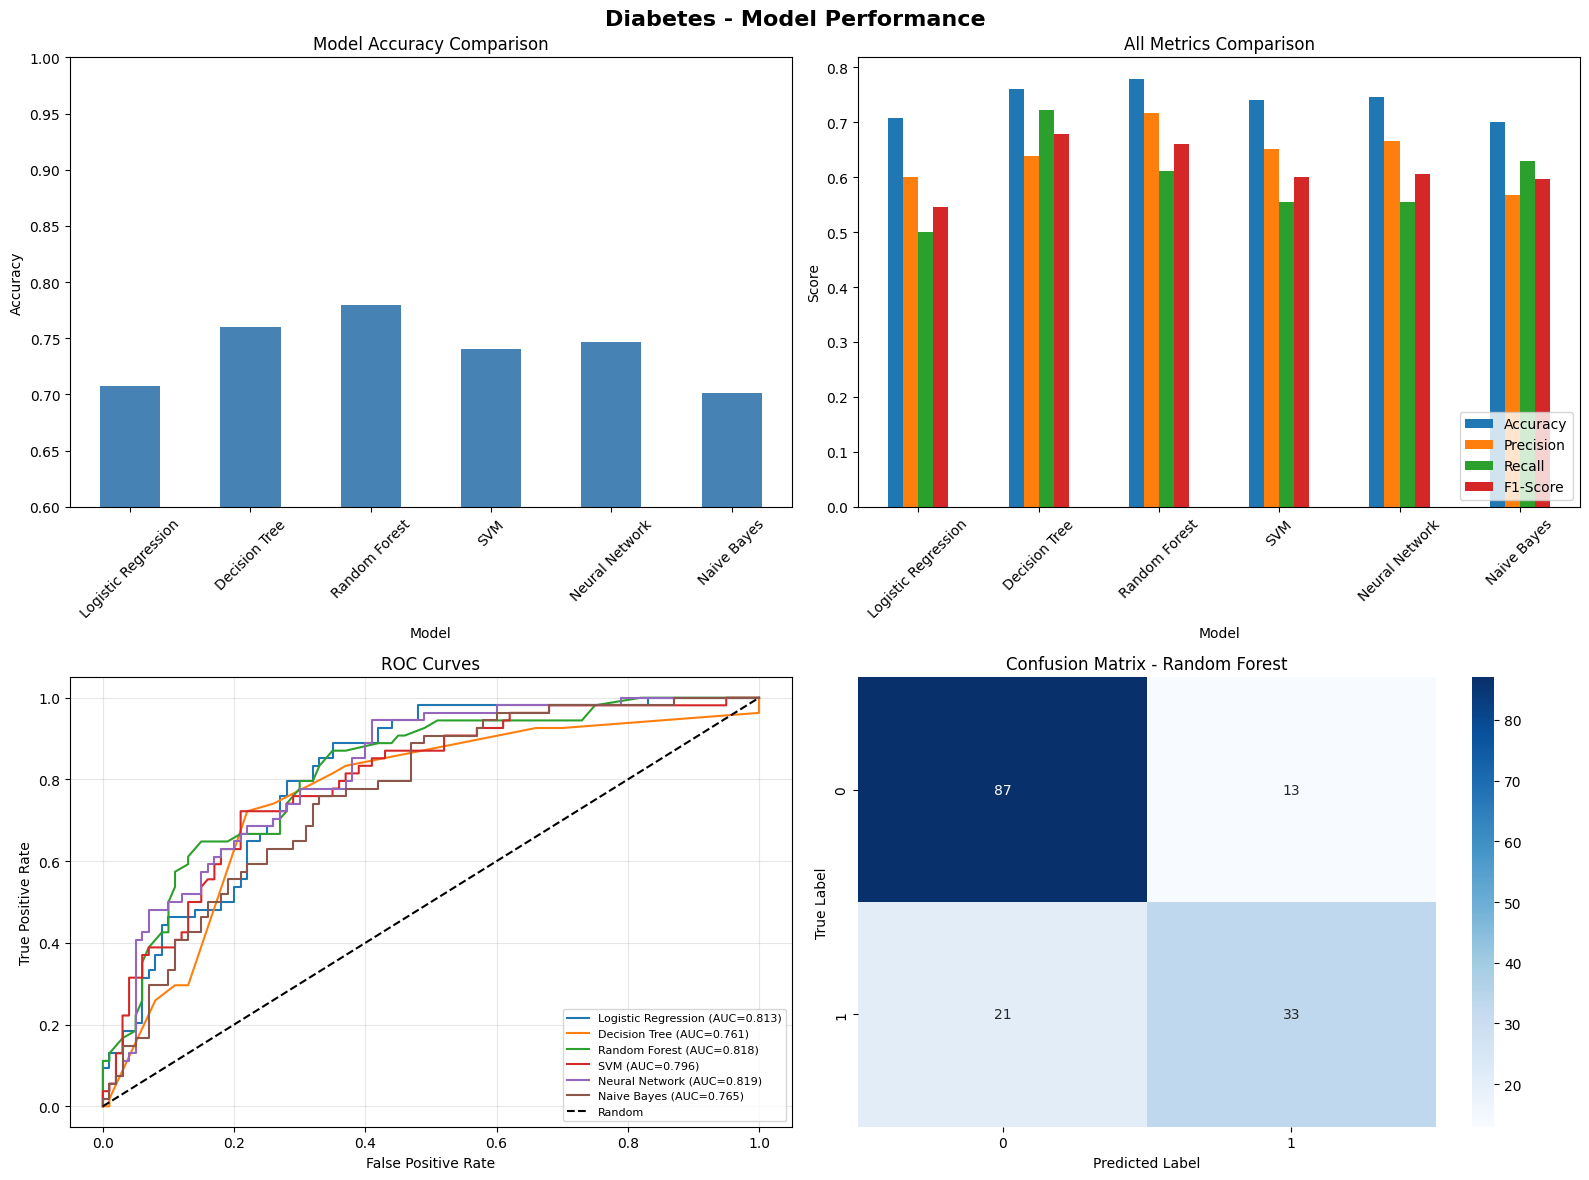


📊 Visualizing Results for Heart Disease...

📋 Model Comparison Table:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.868852   0.812500 0.928571  0.866667 0.951299
      Decision Tree  0.770492   0.705882 0.857143  0.774194 0.803030
      Random Forest  0.885246   0.818182 0.964286  0.885246 0.951299
                SVM  0.852459   0.806452 0.892857  0.847458 0.943723
     Neural Network  0.852459   0.771429 0.964286  0.857143 0.933983
        Naive Bayes  0.868852   0.794118 0.964286  0.870968 0.952381


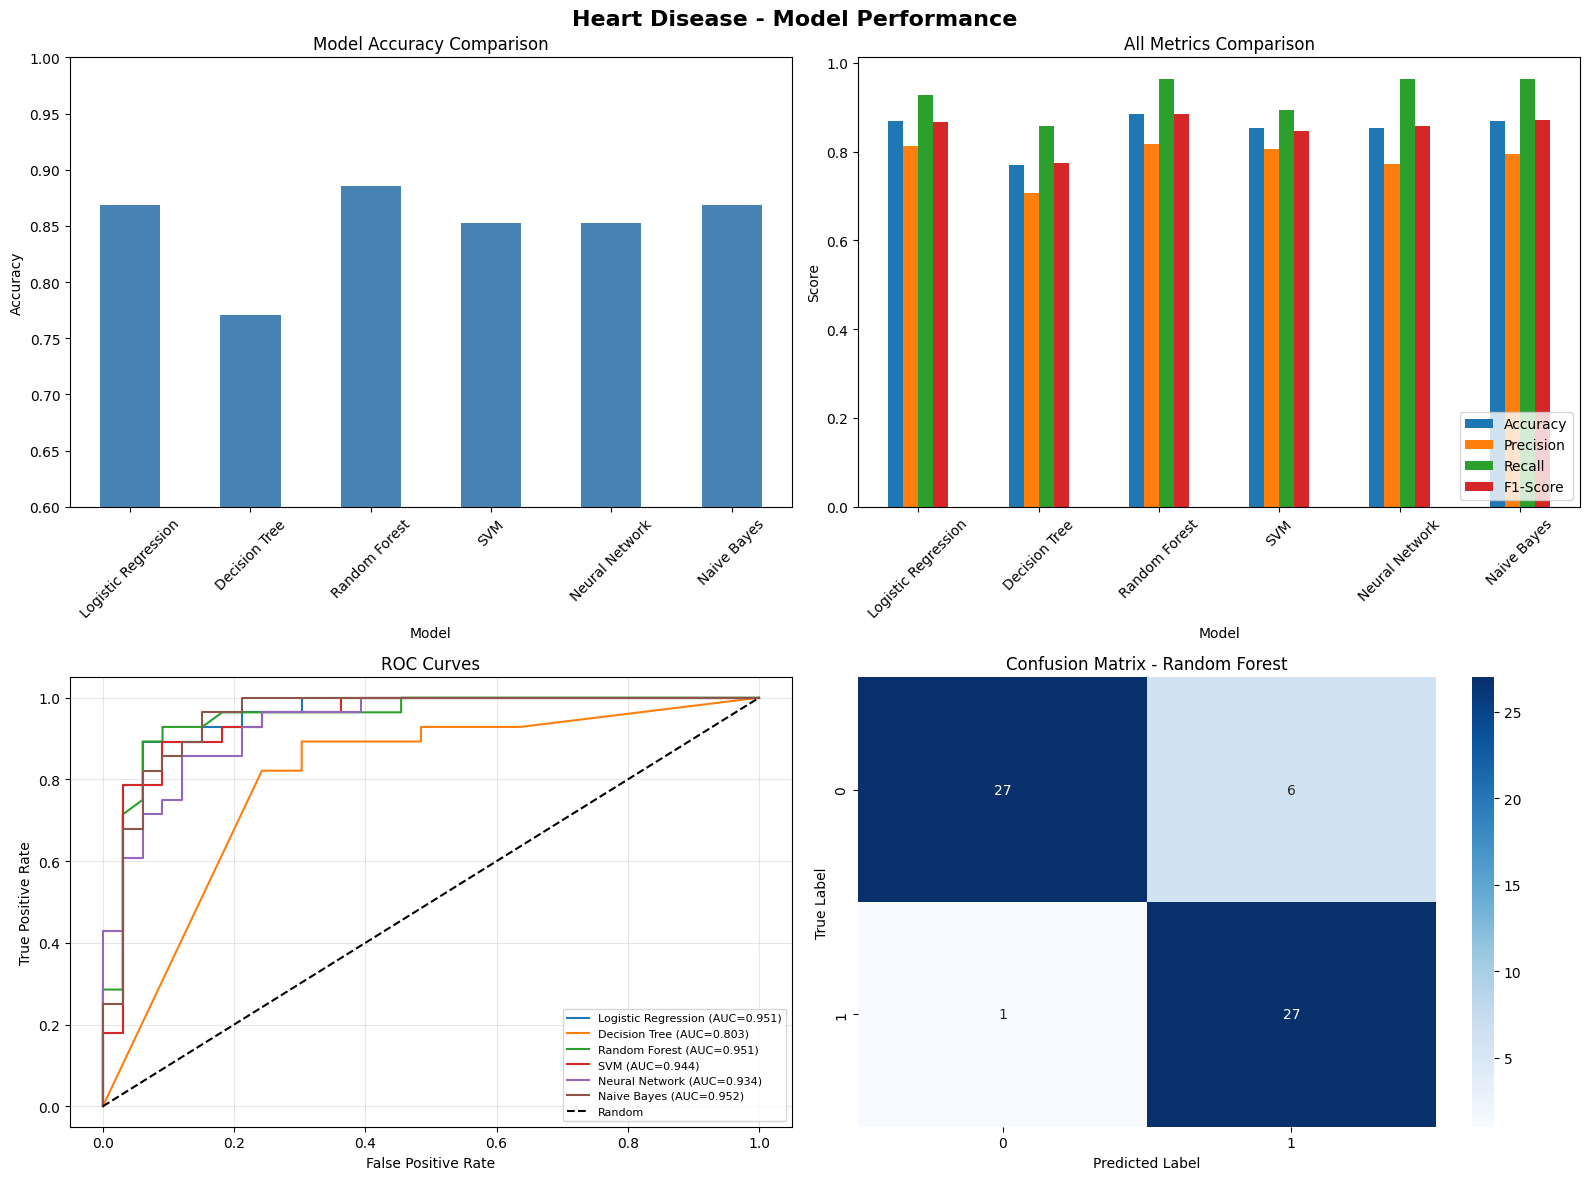


🏆 Best Model for Diabetes: Random Forest
🏆 Best Model for Heart Disease: Random Forest

K-Means Clustering for Diabetes


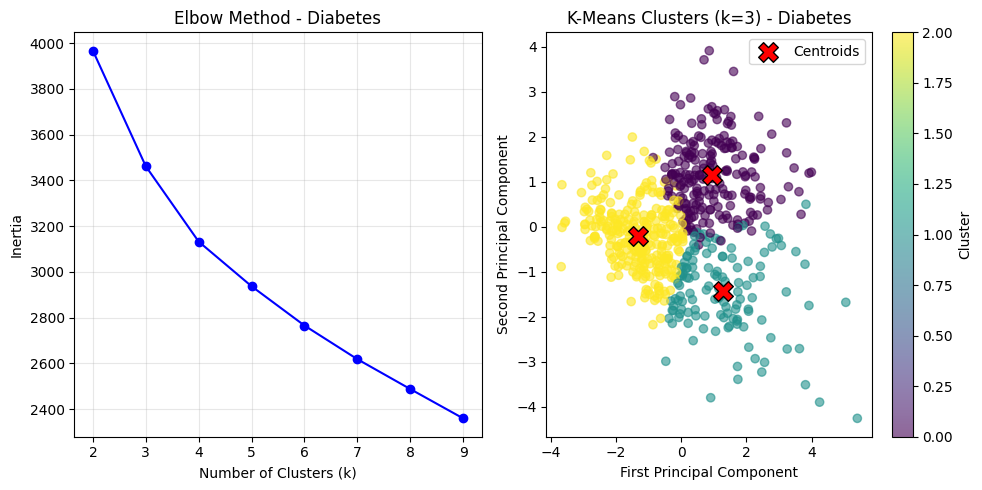


📊 Cluster Distribution:
Cluster 0: 210 patients
  - Disease rate: 49.52%
Cluster 1: 127 patients
  - Disease rate: 59.84%
Cluster 2: 277 patients
  - Disease rate: 12.27%

K-Means Clustering for Heart Disease


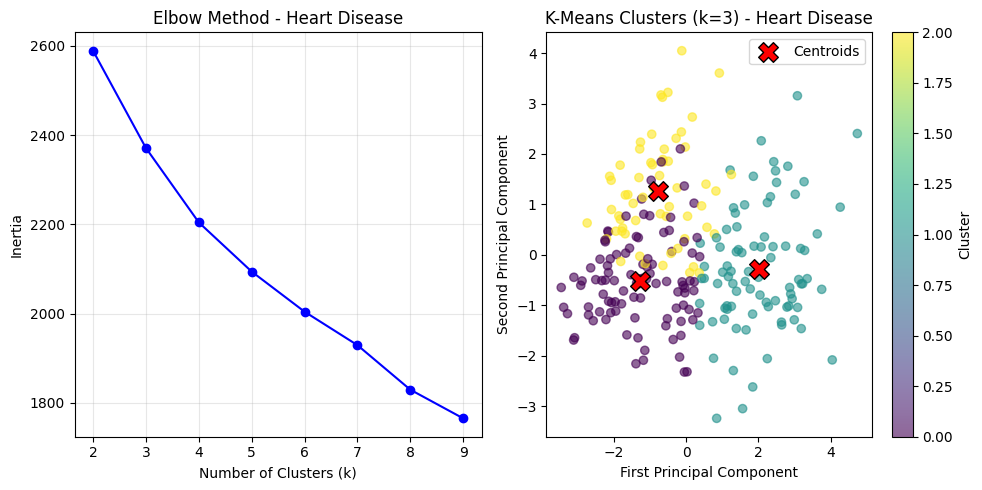


📊 Cluster Distribution:
Cluster 0: 98 patients
  - Disease rate: 27.55%
Cluster 1: 85 patients
  - Disease rate: 89.41%
Cluster 2: 59 patients
  - Disease rate: 13.56%

✅ Models saved successfully!
   - diabetes_model.pkl
   - heart_disease_model.pkl
   - scaler_diabetes.pkl
   - scaler_heart.pkl
SAMPLE PREDICTIONS

🩺 Diabetes Prediction:
   Input: [6, 148, 72, 35, 0, 33.6, 0.627, 50]
   Prediction: Non-Diabetic
   Risk Probability: 50.00%
   Risk Level: Medium

❤️ Heart Disease Prediction:
   Input: [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]
   Prediction: No Heart Disease
   Risk Probability: 19.00%
   Risk Level: Low


In [ ]:
# ========================================
# PREDICTIVE HEALTHCARE ANALYTICS
# Diabetes & Heart Disease Prediction
# ========================================

# ========================================
# STEP 1: INSTALL AND IMPORT LIBRARIES
# ========================================
!pip install streamlit -q
!pip install pyngrok -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

# ========================================
# STEP 2: LOAD DATASETS
# ========================================

# Load Diabetes Dataset (PIMA)
diabetes_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
diabetes_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df_diabetes = pd.read_csv(diabetes_url, names=diabetes_columns)

# Load Heart Disease Dataset (UCI)
heart_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
heart_columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df_heart = pd.read_csv(heart_url, names=heart_columns, na_values='?')

# Convert heart disease to binary (0 = no disease, 1 = disease)
df_heart['target'] = (df_heart['target'] > 0).astype(int)

print("✅ Datasets loaded successfully!")
print(f"\nDiabetes Dataset Shape: {df_diabetes.shape}")
print(f"Heart Disease Dataset Shape: {df_heart.shape}")

# ========================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ========================================

def perform_eda(df, dataset_name, target_col):
    print(f"\n{'='*50}")
    print(f"EDA for {dataset_name}")
    print(f"{'='*50}")

    # Basic info
    print("\n📊 Dataset Info:")
    print(df.info())

    print("\n📈 Statistical Summary:")
    print(df.describe())

    print(f"\n🎯 Target Distribution:")
    print(df[target_col].value_counts())

    # Missing values
    print("\n❓ Missing Values:")
    print(df.isnull().sum())

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'{dataset_name} - EDA Visualizations', fontsize=16, fontweight='bold')

    # Target distribution
    df[target_col].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
    axes[0, 0].set_title('Target Distribution')
    axes[0, 0].set_xlabel('Class')
    axes[0, 0].set_ylabel('Count')

    # Correlation heatmap
    sns.heatmap(df.corr(), annot=False, cmap='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('Feature Correlation Heatmap')

    # Feature distributions (first few features)
    #features = [col for col in df.columns if col != target_col][:4]
    #for idx, feature in enumerate(features[:2]):
    '''    row = 1
        col = idx
        df.boxplot(column=feature, by=target_col, ax=axes[row, col])
        axes[row, col].set_title(f'{feature} by Target')
        axes[row, col].set_xlabel('Target')

    plt.tight_layout()
    plt.show()

# Perform EDA for both datasets
perform_eda(df_diabetes, "Diabetes Dataset (PIMA)", "Outcome")
perform_eda(df_heart, "Heart Disease Dataset (UCI)", "target")'''

# ========================================
# STEP 4: DATA PREPROCESSING
# ========================================

def preprocess_data(df, target_col, dataset_name):
    print(f"\n🔧 Preprocessing {dataset_name}...")

    # Separate features and target
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    # Handle missing values
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # For diabetes dataset, replace zeros with NaN for specific columns
    if dataset_name == "Diabetes":
        zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
        for col in zero_cols:
            if col in X_imputed.columns:
                X_imputed[col] = X_imputed[col].replace(0, np.nan)
        X_imputed = pd.DataFrame(imputer.fit_transform(X_imputed), columns=X_imputed.columns)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"✅ Training set: {X_train_scaled.shape}")
    print(f"✅ Testing set: {X_test_scaled.shape}")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Preprocess both datasets
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes, scaler_diabetes = \
    preprocess_data(df_diabetes, "Outcome", "Diabetes")

X_train_heart, X_test_heart, y_train_heart, y_test_heart, scaler_heart = \
    preprocess_data(df_heart, "target", "Heart Disease")

# ========================================
# STEP 5: MODEL TRAINING & EVALUATION
# ========================================

def train_and_evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    print(f"\n{'='*50}")
    print(f"Training Models for {dataset_name}")
    print(f"{'='*50}")

    # Define models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
        'Naive Bayes': GaussianNB()
    }

    results = {}

    for name, model in models.items():
        print(f"\n🔄 Training {name}...")

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)

        # ROC AUC
        roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

        roc_display = f"{roc_auc:.4f}" if roc_auc is not None else "N/A"
        print(f"✅ {name}: Accuracy={accuracy:.4f}, F1={f1:.4f}, ROC-AUC={roc_display}")

        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'roc_auc': roc_auc,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }

    return results


# Train models for both datasets
results_diabetes = train_and_evaluate_models(
    X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes, "Diabetes"
)

results_heart = train_and_evaluate_models(
    X_train_heart, X_test_heart, y_train_heart, y_test_heart, "Heart Disease"
)


# ========================================
# STEP 6: RESULTS VISUALIZATION
# ========================================

def visualize_results(results, y_test, dataset_name):
    print(f"\n📊 Visualizing Results for {dataset_name}...")

    # Create comparison dataframe
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [r['accuracy'] for r in results.values()],
        'Precision': [r['precision'] for r in results.values()],
        'Recall': [r['recall'] for r in results.values()],
        'F1-Score': [r['f1_score'] for r in results.values()],
        'ROC-AUC': [r['roc_auc'] if r['roc_auc'] else 0 for r in results.values()]
    })

    print("\n📋 Model Comparison Table:")
    print(comparison_df.to_string(index=False))

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{dataset_name} - Model Performance', fontsize=16, fontweight='bold')

    # Accuracy comparison
    comparison_df.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0, 0],
                       color='steelblue', legend=False)
    axes[0, 0].set_title('Model Accuracy Comparison')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_ylim([0.6, 1.0])
    axes[0, 0].tick_params(axis='x', rotation=45)

    # All metrics comparison
    metrics_df = comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
    metrics_df.set_index('Model').plot(kind='bar', ax=axes[0, 1])
    axes[0, 1].set_title('All Metrics Comparison')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].legend(loc='lower right')

    # ROC Curves
    for name, result in results.items():
        if result['y_pred_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
            axes[1, 0].plot(fpr, tpr, label=f"{name} (AUC={result['roc_auc']:.3f})")
    axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curves')
    axes[1, 0].legend(loc='lower right', fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)

    # Confusion Matrix for best model
    best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
    best_result = results[best_model_name]
    cm = confusion_matrix(y_test, best_result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
    axes[1, 1].set_title(f'Confusion Matrix - {best_model_name}')
    axes[1, 1].set_ylabel('True Label')
    axes[1, 1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

    return comparison_df, best_model_name

# Visualize results for both datasets
comparison_diabetes, best_model_diabetes = visualize_results(
    results_diabetes, y_test_diabetes, "Diabetes"
)

comparison_heart, best_model_heart = visualize_results(
    results_heart, y_test_heart, "Heart Disease"
)

print(f"\n🏆 Best Model for Diabetes: {best_model_diabetes}")
print(f"🏆 Best Model for Heart Disease: {best_model_heart}")

# ========================================
# STEP 7: UNSUPERVISED LEARNING (K-MEANS)
# ========================================

def perform_clustering(X_data, y_data, dataset_name):
    print(f"\n{'='*50}")
    print(f"K-Means Clustering for {dataset_name}")
    print(f"{'='*50}")

    # Elbow method
    inertias = []
    K_range = range(2, 10)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_data)
        inertias.append(kmeans.inertia_)

    # Plot elbow curve
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title(f'Elbow Method - {dataset_name}')
    plt.grid(True, alpha=0.3)

    # Perform clustering with optimal k (let's use k=3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_data)

    # Visualize clusters (using first 2 principal components for visualization)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_data)

    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
    plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
                pca.transform(kmeans.cluster_centers_)[:, 1],
                c='red', marker='X', s=200, edgecolors='black', label='Centroids')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title(f'K-Means Clusters (k=3) - {dataset_name}')
    plt.colorbar(scatter, label='Cluster')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Analyze cluster characteristics
    print("\n📊 Cluster Distribution:")
    unique, counts = np.unique(clusters, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"Cluster {cluster_id}: {count} patients")
        cluster_mask = clusters == cluster_id
        print(f"  - Disease rate: {y_data[cluster_mask].mean():.2%}")

# Perform clustering
perform_clustering(X_train_diabetes, y_train_diabetes, "Diabetes")
perform_clustering(X_train_heart, y_train_heart, "Heart Disease")

# ========================================
# STEP 8: SAVE MODELS
# ========================================

import joblib

# Save best models
best_diabetes_model = results_diabetes[best_model_diabetes]['model']
best_heart_model = results_heart[best_model_heart]['model']

joblib.dump(best_diabetes_model, 'diabetes_model.pkl')
joblib.dump(best_heart_model, 'heart_disease_model.pkl')
joblib.dump(scaler_diabetes, 'scaler_diabetes.pkl')
joblib.dump(scaler_heart, 'scaler_heart.pkl')

print("\n✅ Models saved successfully!")
print("   - diabetes_model.pkl")
print("   - heart_disease_model.pkl")
print("   - scaler_diabetes.pkl")
print("   - scaler_heart.pkl")

# ========================================
# STEP 9: PREDICTION FUNCTION
# ========================================

def predict_diabetes(features):
    """
    Predict diabetes risk
    features: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
    """
    features_scaled = scaler_diabetes.transform([features])
    prediction = best_diabetes_model.predict(features_scaled)[0]
    probability = best_diabetes_model.predict_proba(features_scaled)[0][1]

    return {
        'prediction': 'Diabetic' if prediction == 1 else 'Non-Diabetic',
        'risk_probability': f"{probability:.2%}",
        'risk_level': 'High' if probability > 0.7 else 'Medium' if probability > 0.4 else 'Low'
    }

def predict_heart_disease(features):
    """
    Predict heart disease risk
    features: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]
    """
    features_scaled = scaler_heart.transform([features])
    prediction = best_heart_model.predict(features_scaled)[0]
    probability = best_heart_model.predict_proba(features_scaled)[0][1]

    return {
        'prediction': 'Heart Disease' if prediction == 1 else 'No Heart Disease',
        'risk_probability': f"{probability:.2%}",
        'risk_level': 'High' if probability > 0.7 else 'Medium' if probability > 0.4 else 'Low'
    }

# Test predictions
print("SAMPLE PREDICTIONS")

# Sample diabetes prediction
sample_diabetes = [6, 148, 72, 35, 0, 33.6, 0.627, 50]  # High risk patient
result = predict_diabetes(sample_diabetes)
print("\n🩺 Diabetes Prediction:")
print(f"   Input: {sample_diabetes}")
print(f"   Prediction: {result['prediction']}")
print(f"   Risk Probability: {result['risk_probability']}")
print(f"   Risk Level: {result['risk_level']}")

# Sample heart disease prediction
sample_heart = [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]  # Sample patient
result = predict_heart_disease(sample_heart)
print("\n❤️ Heart Disease Prediction:")
print(f"   Input: {sample_heart}")
print(f"   Prediction: {result['prediction']}")
print(f"   Risk Probability: {result['risk_probability']}")
print(f"   Risk Level: {result['risk_level']}")

In [ ]:
!pip install streamlit pyngrok plotly -q
print("✅ All packages installed!")

✅ All packages installed!


In [ ]:
# Create the Streamlit app
app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go

st.set_page_config(page_title="Healthcare ML", page_icon="🏥", layout="wide")

st.markdown("""
<style>
    .main-header {font-size: 42px; font-weight: bold; color: #1f77b4; text-align: center;}
    .prediction-box {padding: 20px; border-radius: 10px; margin: 10px 0;}
    .high-risk {background-color: #ffebee; border-left: 5px solid #f44336;}
    .medium-risk {background-color: #fff3e0; border-left: 5px solid #ff9800;}
    .low-risk {background-color: #e8f5e9; border-left: 5px solid #4caf50;}
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_models():
    try:
        diabetes_model = joblib.load('diabetes_model.pkl')
        heart_model = joblib.load('heart_disease_model.pkl')
        scaler_diabetes = joblib.load('scaler_diabetes.pkl')
        scaler_heart = joblib.load('scaler_heart.pkl')
        return diabetes_model, heart_model, scaler_diabetes, scaler_heart, None
    except Exception as e:
        return None, None, None, None, str(e)

st.markdown('<div class="main-header">🏥 Healthcare Predictive Analytics</div>', unsafe_allow_html=True)
st.markdown('<div style="text-align: center; color: #666; margin-bottom: 30px;">MIT Anna University | ML-Powered Disease Risk Assessment</div>', unsafe_allow_html=True)

st.sidebar.title("Navigation")
page = st.sidebar.radio("Select Disease", ["🩺 Diabetes", "❤️ Heart Disease", "📊 About"])

diabetes_model, heart_model, scaler_diabetes, scaler_heart, error = load_models()

if error:
    st.error(f"⚠️ Error: {error}")
    st.info("Make sure the .pkl files are in /content/ directory")
    st.stop()

if page == "🩺 Diabetes":
    st.header("Diabetes Risk Assessment")

    col1, col2 = st.columns(2)
    with col1:
        pregnancies = st.number_input("Pregnancies", 0, 20, 1)
        glucose = st.number_input("Glucose (mg/dL)", 0, 300, 120)
        bp = st.number_input("Blood Pressure (mm Hg)", 0, 200, 70)
        skin = st.number_input("Skin Thickness (mm)", 0, 100, 20)
    with col2:
        insulin = st.number_input("Insulin (mu U/ml)", 0, 900, 80)
        bmi = st.number_input("BMI", 0.0, 70.0, 25.0, 0.1)
        dpf = st.number_input("Diabetes Pedigree", 0.0, 3.0, 0.5, 0.01)
        age = st.number_input("Age", 1, 120, 30)

    if st.button("🔍 Predict Diabetes Risk", type="primary", use_container_width=True):
        features = np.array([[pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]])
        features_scaled = scaler_diabetes.transform(features)
        prediction = diabetes_model.predict(features_scaled)[0]
        probability = diabetes_model.predict_proba(features_scaled)[0][1]

        risk_level = "High" if probability > 0.7 else "Medium" if probability > 0.4 else "Low"
        risk_class = "high-risk" if probability > 0.7 else "medium-risk" if probability > 0.4 else "low-risk"
        color = "#f44336" if probability > 0.7 else "#ff9800" if probability > 0.4 else "#4caf50"

        st.markdown("---")
        col1, col2, col3 = st.columns(3)
        col1.metric("Diagnosis", "Diabetic" if prediction == 1 else "Non-Diabetic")
        col2.metric("Risk Probability", f"{probability:.1%}")
        col3.metric("Risk Level", risk_level)

        fig = go.Figure(go.Indicator(
            mode="gauge+number", value=probability * 100,
            title={'text': "Risk Score"},
            gauge={'axis': {'range': [None, 100]}, 'bar': {'color': color},
                   'steps': [{'range': [0, 40], 'color': "#e8f5e9"},
                            {'range': [40, 70], 'color': "#fff3e0"},
                            {'range': [70, 100], 'color': "#ffebee"}]}
        ))
        fig.update_layout(height=300)
        st.plotly_chart(fig, use_container_width=True)

        st.markdown(f'<div class="prediction-box {risk_class}"><h3>📋 Recommendations</h3>', unsafe_allow_html=True)
        if risk_level == "High":
            st.markdown("""
            - ⚠️ **Immediate Action Required**: Consult an endocrinologist
            - 🍎 Follow a strict diabetic diet plan
            - 💊 Medication may be necessary
            - 🏃 Regular exercise (30 min/day)
            - 📊 Monitor blood glucose daily
            """)
        elif risk_level == "Medium":
            st.markdown("""
            - ⚡ **Preventive Measures Recommended**
            - 🥗 Maintain a balanced diet, reduce sugar intake
            - 🏃 Exercise regularly (150 min/week)
            - ⚖️ Maintain healthy weight
            - 🔬 Regular check-ups every 6 months
            """)
        else:
            st.markdown("""
            - ✅ **Good Health Status**
            - 🥗 Continue healthy eating habits
            - 🏃 Stay physically active
            - 🔬 Annual health screening recommended
            - 📚 Stay informed about diabetes prevention
            """)
        st.markdown('</div>', unsafe_allow_html=True)

elif page == "❤️ Heart Disease":
    st.header("Heart Disease Risk Assessment")

    col1, col2, col3 = st.columns(3)
    with col1:
        age = st.number_input("Age", 1, 120, 50)
        sex = st.selectbox("Sex", [("Male", 1), ("Female", 0)], format_func=lambda x: x[0])
        cp = st.selectbox("Chest Pain", [("Typical Angina", 0), ("Atypical Angina", 1),
                                         ("Non-anginal", 2), ("Asymptomatic", 3)], format_func=lambda x: x[0])
        trestbps = st.number_input("Resting BP (mm Hg)", 80, 200, 120)
        chol = st.number_input("Cholesterol (mg/dL)", 100, 600, 200)
    with col2:
        fbs = st.selectbox("Fasting BS > 120", [("No", 0), ("Yes", 1)], format_func=lambda x: x[0])
        restecg = st.selectbox("Resting ECG", [("Normal", 0), ("ST-T Abnormality", 1),
                                                ("LV Hypertrophy", 2)], format_func=lambda x: x[0])
        thalach = st.number_input("Max Heart Rate", 60, 220, 150)
        exang = st.selectbox("Exercise Angina", [("No", 0), ("Yes", 1)], format_func=lambda x: x[0])
    with col3:
        oldpeak = st.number_input("ST Depression", 0.0, 10.0, 1.0, 0.1)
        slope = st.selectbox("ST Slope", [("Upsloping", 0), ("Flat", 1), ("Downsloping", 2)], format_func=lambda x: x[0])
        ca = st.number_input("Major Vessels (0-3)", 0, 3, 0)
        thal = st.selectbox("Thalassemia", [("Normal", 1), ("Fixed", 2), ("Reversible", 3)], format_func=lambda x: x[0])

    if st.button("🔍 Predict Heart Disease Risk", type="primary", use_container_width=True):
        features = np.array([[age, sex[1], cp[1], trestbps, chol, fbs[1], restecg[1],
                             thalach, exang[1], oldpeak, slope[1], ca, thal[1]]])
        features_scaled = scaler_heart.transform(features)
        prediction = heart_model.predict(features_scaled)[0]
        probability = heart_model.predict_proba(features_scaled)[0][1]

        risk_level = "High" if probability > 0.7 else "Medium" if probability > 0.4 else "Low"
        risk_class = "high-risk" if probability > 0.7 else "medium-risk" if probability > 0.4 else "low-risk"
        color = "#f44336" if probability > 0.7 else "#ff9800" if probability > 0.4 else "#4caf50"

        st.markdown("---")
        col1, col2, col3 = st.columns(3)
        col1.metric("Diagnosis", "Heart Disease" if prediction == 1 else "No Disease")
        col2.metric("Risk Probability", f"{probability:.1%}")
        col3.metric("Risk Level", risk_level)

        fig = go.Figure(go.Indicator(
            mode="gauge+number", value=probability * 100,
            title={'text': "Risk Score"},
            gauge={'axis': {'range': [None, 100]}, 'bar': {'color': color},
                   'steps': [{'range': [0, 40], 'color': "#e8f5e9"},
                            {'range': [40, 70], 'color': "#fff3e0"},
                            {'range': [70, 100], 'color': "#ffebee"}]}
        ))
        fig.update_layout(height=300)
        st.plotly_chart(fig, use_container_width=True)

        st.markdown(f'<div class="prediction-box {risk_class}"><h3>📋 Recommendations</h3>', unsafe_allow_html=True)
        if risk_level == "High":
            st.markdown("""
            - ⚠️ **Urgent Medical Attention Required**: See a cardiologist immediately
            - 💊 May require medication or intervention
            - 🏥 Comprehensive cardiac evaluation needed
            - 🚭 Stop smoking immediately if applicable
            - 🧂 Strict low-sodium, heart-healthy diet
            - 🏃 Supervised exercise program
            """)
        elif risk_level == "Medium":
            st.markdown("""
            - ⚡ **Preventive Care Recommended**
            - 🏥 Schedule cardiac screening
            - 🥗 Heart-healthy diet (low fat, low sodium)
            - 🏃 Regular moderate exercise
            - 💊 Monitor blood pressure and cholesterol
            - 😴 Manage stress and get adequate sleep
            """)
        else:
            st.markdown("""
            - ✅ **Good Cardiovascular Health**
            - 🥗 Continue heart-healthy lifestyle
            - 🏃 Maintain regular physical activity
            - 🔬 Annual cardiovascular check-ups
            - 📚 Stay informed about heart health
            """)
        st.markdown('</div>', unsafe_allow_html=True)

else:
    st.header("About This System")
    st.markdown("""
    ### 🎯 Project Overview
    Predictive Healthcare Analytics using Machine Learning for diabetes and heart disease detection.

    ### 🔬 ML Models (Scikit-learn)
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - SVM
    - Neural Network
    - Naive Bayes
    - K-Means Clustering

    ### 📊 Datasets
    - **PIMA Diabetes**: 768 patients, 8 features
    - **UCI Heart Disease**: 303 patients, 13 features

    ### 👥 Developed By
    **Sripathy V** (2023506113) & **Dinitha Poola** (2023506127)
    Department of Information Technology, MIT Anna University

    ### ⚠️ Disclaimer
    For educational purposes only. Consult healthcare professionals for medical decisions.
    """)

st.markdown("---")
st.markdown('<div style="text-align: center; color: #666;">🏥 Healthcare ML System v1.0 | MIT Anna University 2024-25</div>', unsafe_allow_html=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py created successfully in /content/")

✅ app.py created successfully in /content/


In [ ]:
!ngrok authtoken 34q6epr8YE4joqHfX2u2YetECWH_4hU2uDXGJtFCGujiMkG6T

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
import subprocess
import time

# Kill any existing streamlit
!pkill -9 streamlit 2>/dev/null

# Start streamlit
print("🚀 Starting Streamlit server...")
process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8000', '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait for startup
time.sleep(8)

# Create public URL
try:
    public_url = ngrok.connect(8000)

    print("\n" + "="*70)
    print("🎉 YOUR APP IS LIVE!")
    print("="*70)
    print(f"\n🌐 Public URL: {public_url}")
    print("\n📱 Click the link above to access your Healthcare ML Dashboard")
    print("\n💡 Tips:")
    print("   • Share this URL with anyone to demo your project")
    print("   • App stays live as long as this cell runs")
    print("   • Press stop button ⬛ to shut down")
    print("="*70)

except Exception as e:
    print(f"❌ Error: {e}")
    print("💡 Try restarting runtime and running again")

🚀 Starting Streamlit server...

🎉 YOUR APP IS LIVE!

🌐 Public URL: NgrokTunnel: "https://prenuptial-spryest-claudette.ngrok-free.dev" -> "http://localhost:8000"

📱 Click the link above to access your Healthcare ML Dashboard

💡 Tips:
   • Share this URL with anyone to demo your project
   • App stays live as long as this cell runs
   • Press stop button ⬛ to shut down


In [ ]:
# Check if models exist
!ls -lh *.pkl

-rw-r--r-- 1 root root 1.7M Nov  7 05:29 diabetes_model.pkl
-rw-r--r-- 1 root root 735K Nov  7 05:29 heart_disease_model.pkl
-rw-r--r-- 1 root root 1.2K Nov  7 05:29 scaler_diabetes.pkl
-rw-r--r-- 1 root root 1.3K Nov  7 05:29 scaler_heart.pkl


In [ ]:
# Restart and try again
!pkill -9 ngrok
# Then rerun Cell 4